# Knowledge Graph Entity Classification -- Wikidata5m

**Course:** KASDAD -- Universitas Indonesia, Fourth Semester  
**Group:** 5B  
**Date:** 2026-05-23

| No | Name | NPM |
|----|------|-----|
| 1 | Gunata Prajna Putra Sakri | 2406453461 |
| 2 | Melanton Gabriel Siregar | 2406365364 |
| 3 | Muhammad Vegard Fathul Islam | 2406365332 |
| 4 | Roben Joseph Buce Tambayong | 2406453594 |

## AI Disclosure

In accordance with assignment rules, we disclose the following AI tool usage:

| Tool | How it was used |
|------|-----------------|
| Claude (Anthropic) | Generating the filtering script skeleton, notebook structure, and .gitignore / README templates |

All code was reviewed, tested, and adapted by team members. Final analytical decisions, interpretations, and written sections are our own.

In [1]:
import os
import json
import random

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

random.seed(42)
np.random.seed(42)
print('Imports OK')

Imports OK


## Section 1 — Business Understanding

### 1.1 What is a Knowledge Graph?

A **knowledge graph** is a structured representation of real-world entities and the relationships between them. Entities — people, places, works, or organisms — form the *nodes* of the graph, while directed, labelled edges encode the *relationships* (predicates) between them. Data is stored as **RDF triples** of the form `Subject–Predicate–Object`, for example: *Douglas Adams* —educated at→ *St John's College, Cambridge*. This triple-based model allows heterogeneous facts to be combined in a single queryable structure, making knowledge graphs the backbone of modern information retrieval, search engines, and question-answering systems.

### 1.2 What is Wikidata and Wikidata5m?

**Wikidata** is a free, collaboratively edited, multilingual knowledge graph maintained by the Wikimedia Foundation. It assigns unique identifiers to every concept: **Q-codes** for entities (e.g. Q5 = *human*, Q90 = *Paris*) and **P-codes** for properties (e.g. P31 = *instance of*, P57 = *director*). As of 2026, Wikidata contains over 100 million statements across tens of millions of items.

**Wikidata5m** (Wang et al., 2021) is a curated million-scale research subset of Wikidata designed for knowledge graph embedding and downstream NLP tasks. It contains approximately 4.8 million entities, 825 relation types, and 56 million triples — large enough to reflect the statistical properties of the full graph while remaining tractable for academic research.

### 1.3 Problem Formulation

Our task is **multiclass entity classification**: given an entity from Wikidata5m, predict which of five semantic types it belongs to, using only the *set of Wikidata property codes (P-codes)* that the entity possesses — not the property values themselves. The five target classes are:

| Q-code | Class | Description |
|--------|-------|-------------|
| Q5 | human | A biological human person |
| Q571 | book | A written work published as a book |
| Q532 | village | A small human settlement |
| Q16521 | taxon | A biological taxon (species, genus, family, etc.) |
| Q11424 | film | A motion picture |


The input to the classifier is a **binary feature matrix**: each row is an entity, each column is a P-code, and the value is 1 if the entity has that property in the knowledge graph and 0 otherwise. The property **P31** (*instance of*) is explicitly excluded from all features because it directly encodes the class label — using it would constitute data leakage. Excluding property *values* (rather than just the property code's presence) is a deliberate design choice: it reduces noise from free-text or numeric values, avoids the curse of dimensionality introduced by high-cardinality object sets, and produces a compact binary representation that is compatible with sparse linear classifiers and tree-based models.

### 1.4 Real-World Motivation

Knowledge graph completion is a central challenge in AI. Millions of Wikidata entities currently lack a P31 (*instance of*) triple, which means their semantic type is unknown. Automatic type prediction can (1) fill these gaps at scale without manual curation, (2) improve the relevance of Google Knowledge Panel cards and similar structured-data displays, (3) enable semantic reasoning in downstream systems such as recommendation engines and question-answering pipelines, and (4) accelerate scientific knowledge management — for example, automatically classifying newly discovered biological taxa.

### 1.5 Success Criteria

With five equally represented classes, a random classifier achieves **20% macro F1**. Our minimum acceptance target is **macro F1 > 0.85** on a held-out stratified test set by the end of Week 3. We select **macro-averaged F1** as the primary metric because it reports per-class precision and recall independently, making it invariant to accidental class-size drift in future dataset versions and revealing failures on underperforming classes that accuracy would mask.


In [2]:
print('Section 1: Business Understanding')

Section 1: Business Understanding


## Section 2 -- Data Understanding

The dataset is derived from **Wikidata5m**, a large-scale knowledge graph containing ~5 million entities and ~20 million triples.  
We filter for five entity classes using the `P31` (instance-of) relation:

| Qcode | Class |
|-------|-------|
| Q5 | human |
| Q571 | book |
| Q532 | village |
| Q16521 | taxon |
| Q11424 | film |

Up to 2000 entities are sampled per class (random seed 42).

In [3]:
FILTERED_CSV = os.path.join('data', 'raw', 'entities_filtered.csv')

df = pd.read_csv(FILTERED_CSV)
print('Shape:', df.shape)
print()
print('Class distribution:')
print(df.groupby(['class_qcode', 'class_name']).size().reset_index(name='count'))

Shape: (10000, 3)

Class distribution:
  class_qcode class_name  count
0      Q11424       film   2000
1      Q16521      taxon   2000
2          Q5      human   2000
3        Q532    village   2000
4        Q571       book   2000


### 2.2 Property Extraction

For each entity we collect every Wikidata predicate (P-code) that appears in the raw triples, **excluding P31** (instance-of) because that encodes the classification label.  
The extraction streams the multi-GB triples file line-by-line without loading it into RAM.  
Results are saved to `data/raw/entity_properties.json`.

> **To run once from the terminal:**  
> `python src/extract_properties.py --input wikidata5m_all_triplet.txt`

In [4]:
import csv, json, os

TRIPLES_PATH  = "wikidata5m_all_triplet.txt"
ENTITIES_CSV  = os.path.join("data", "raw", "entities_filtered.csv")
OUTPUT_JSON   = os.path.join("data", "raw", "entity_properties.json")
LABEL_PRED    = "P31"   # instance-of — excluded because it IS the label
PROGRESS_STEP = 5_000_000

if os.path.exists(OUTPUT_JSON):
    # outputs already exist — skip the multi-GB stream and just report stats
    with open(OUTPUT_JSON, encoding="utf-8") as fh:
        props_loaded = json.load(fh)
    counts    = [len(v) for v in props_loaded.values()]
    all_props = {p for codes in props_loaded.values() for p in codes}
    print(f"[SKIP] {OUTPUT_JSON} already exists — skipping triple stream.")
    print(f"Unique property codes : {len(all_props):,}")
    print(f"Entities with props   : {sum(1 for c in counts if c > 0):,} / {len(counts):,}")
    print(f"Avg props per entity  : {sum(counts)/len(counts):.1f}")
    print(f"Min / Max             : {min(counts)} / {max(counts)}")
else:
    # --- load entity set ---
    entity_set = set()
    with open(ENTITIES_CSV, newline="", encoding="utf-8") as fh:
        for row in csv.DictReader(fh):
            entity_set.add(row["entity_id"])
    print(f"Entities loaded: {len(entity_set):,}")

    # --- stream triples: single pass, no full-RAM load ---
    props = {eid: set() for eid in entity_set}
    line_count = match_count = 0

    # errors="replace" swaps bad bytes for U+FFFD instead of crashing
    with open(TRIPLES_PATH, "r", encoding="utf-8", errors="replace") as fh:
        for line in fh:
            line_count += 1
            if line_count % PROGRESS_STEP == 0:
                print(f"  {line_count:,} lines ... {match_count:,} matches")
            parts = line.rstrip("\n").split("\t")
            if len(parts) != 3:
                continue
            subject, predicate, _ = parts
            if subject not in entity_set or predicate == LABEL_PRED:
                continue
            props[subject].add(predicate)
            match_count += 1

    print(f"Done: {line_count:,} lines | {match_count:,} assignments")

    counts    = [len(v) for v in props.values()]
    all_props = {p for codes in props.values() for p in codes}
    print(f"\nUnique property codes : {len(all_props):,}")
    print(f"Entities with props   : {sum(1 for c in counts if c > 0):,} / {len(counts):,}")
    print(f"Avg props per entity  : {sum(counts)/len(counts):.1f}")
    print(f"Min / Max             : {min(counts)} / {max(counts)}")

    os.makedirs(os.path.dirname(OUTPUT_JSON), exist_ok=True)
    serializable = {eid: sorted(codes) for eid, codes in props.items()}
    with open(OUTPUT_JSON, "w", encoding="utf-8") as fh:
        json.dump(serializable, fh, separators=(",", ":"))
    print(f"\nSaved: {OUTPUT_JSON}")


[SKIP] data/raw/entity_properties.json already exists — skipping triple stream.
Unique property codes : 172
Entities with props   : 9,769 / 10,000
Avg props per entity  : 3.7
Min / Max             : 0 / 21


### 2.3 Feature Matrix Construction

We build a **binary sparse matrix** (scipy CSR format) where:
- Each **row** is one of our 10 000 entities (same order as `entities_filtered.csv`).
- Each **column** is a unique property P-code collected in 2.2 (P31 excluded).
- A cell is **1** if the entity has that property, **0** otherwise.

COO format is used as an intermediate step — we collect `(row, col)` pairs cheaply then convert to CSR in one shot, which is much faster than per-element insertion.

> **To run once from the terminal:**  
> `python src/build_feature_matrix.py`

In [5]:
import csv, json, os
import numpy as np
import scipy.sparse as sp

ENTITIES_CSV = os.path.join("data", "raw", "entities_filtered.csv")
PROPS_JSON   = os.path.join("data", "raw", "entity_properties.json")
OUT_MATRIX   = os.path.join("data", "processed", "feature_matrix.npz")
OUT_COLUMNS  = os.path.join("data", "processed", "feature_matrix_columns.json")
OUT_LABELS   = os.path.join("data", "processed", "labels.csv")

# --- load entity order (defines row order of the matrix) ---
entity_order = []
with open(ENTITIES_CSV, newline="", encoding="utf-8") as fh:
    for row in csv.DictReader(fh):
        entity_order.append((row["entity_id"], row["class_qcode"], row["class_name"]))
print(f"Entities loaded: {len(entity_order):,}")

# --- load property sets ---
with open(PROPS_JSON, encoding="utf-8") as fh:
    props = json.load(fh)
print(f"Property JSON loaded: {len(props):,} entities")

# --- build sorted vocabulary (= column names) ---
all_prop_codes = {p for eid, _, _ in entity_order for p in props.get(eid, [])}
# P31 must not appear — it is the label, excluded during extraction
assert "P31" not in all_prop_codes, "P31 leaked into features!"
vocab = sorted(all_prop_codes)
print(f"Vocabulary size: {len(vocab):,} unique properties")

# --- build COO data then convert to CSR ---
prop_to_idx = {p: i for i, p in enumerate(vocab)}
row_idx_list, col_idx_list = [], []

for row_idx, (entity_id, _, _) in enumerate(entity_order):
    for prop in props.get(entity_id, []):
        col_idx = prop_to_idx.get(prop)
        if col_idx is not None:
            row_idx_list.append(row_idx)
            col_idx_list.append(col_idx)

data   = np.ones(len(row_idx_list), dtype=np.uint8)
matrix = sp.coo_matrix(
    (data, (row_idx_list, col_idx_list)),
    shape=(len(entity_order), len(vocab)),
).tocsr()

# sanity checks
assert matrix.shape[0] == len(entity_order)
assert matrix.shape[1] == len(vocab)
print(f"Matrix shape: {matrix.shape[0]:,} × {matrix.shape[1]:,}  ✓")

# --- statistics ---
nnz     = matrix.nnz
density = nnz / (matrix.shape[0] * matrix.shape[1]) * 100
mem_mb  = (matrix.data.nbytes + matrix.indices.nbytes + matrix.indptr.nbytes) / 1024**2
print(f"Non-zero entries : {nnz:,}")
print(f"Density          : {density:.4f}%")
print(f"In-memory (CSR)  : {mem_mb:.2f} MB")

# --- save outputs ---
os.makedirs(os.path.dirname(OUT_MATRIX), exist_ok=True)
sp.save_npz(OUT_MATRIX, matrix)

with open(OUT_COLUMNS, "w", encoding="utf-8") as fh:
    json.dump(vocab, fh, separators=(",", ":"))

with open(OUT_LABELS, "w", newline="", encoding="utf-8") as fh:
    writer = csv.writer(fh)
    writer.writerow(["entity_id", "class_name", "class_qcode"])
    for entity_id, class_qcode, class_name in entity_order:
        writer.writerow([entity_id, class_name, class_qcode])

print(f"\nSaved: {OUT_MATRIX}")
print(f"Saved: {OUT_COLUMNS}")
print(f"Saved: {OUT_LABELS}")

Entities loaded: 10,000
Property JSON loaded: 10,000 entities
Vocabulary size: 172 unique properties
Matrix shape: 10,000 × 172  ✓
Non-zero entries : 37,120
Density          : 2.1581%
In-memory (CSR)  : 0.22 MB

Saved: data/processed/feature_matrix.npz
Saved: data/processed/feature_matrix_columns.json
Saved: data/processed/labels.csv


### 2.4 Property Name Lookup

We build two human-readable name dictionaries from the Wikidata5m alias files:

| File | Content |
|---|---|
| `wikidata5m_relation.txt` | 825 lines, each: `P-code TAB primary-alias TAB ...` |
| `wikidata5m_entity.txt` | 4.8M lines, each: `Q-code TAB primary-alias TAB ...` |

> **Data quality note:** the entity file's first alias for some of our target classes is unreliable (`Q5` → `'Huamn'`, `Q571` → `'wikipedia books/sandbox'`). We use hardcoded canonical names from `filter_entities.py` instead.

> **To run once from the terminal:**  
> `python src/build_property_names.py`

In [6]:
import json, os

RELATIONS_FILE = "wikidata5m_relation.txt"
ENTITIES_FILE  = "wikidata5m_entity.txt"
OUT_PROPS      = os.path.join("data", "raw", "property_names.json")
OUT_CLASSES    = os.path.join("data", "raw", "class_names.json")

TARGET_CLASSES = {
    "Q5":     "human",
    "Q571":   "book",
    "Q532":   "village",
    "Q16521": "taxon",
    "Q11424": "film",
}

if os.path.exists(OUT_PROPS) and os.path.exists(OUT_CLASSES):
    # outputs already exist — skip the alias file stream and just report
    with open(OUT_PROPS, encoding="utf-8") as fh:
        prop_names = json.load(fh)
    with open(OUT_CLASSES, encoding="utf-8") as fh:
        class_names = json.load(fh)
    print(f"[SKIP] {OUT_PROPS} already exists — skipping alias file stream.")
    print(f"Property codes loaded : {len(prop_names):,}")
    print(f"Class names loaded    : {class_names}")
    print("\nSample property name lookups:")
    for p, name in list(prop_names.items())[:10]:
        print(f"  {p:<10} {name}")
else:
    # --- load P-code -> primary alias from relation file ---
    prop_names = {}
    with open(RELATIONS_FILE, encoding="utf-8", errors="replace") as fh:
        for line in fh:
            parts = line.rstrip("\n").split("\t")
            if not parts[0].startswith("P"):
                continue
            p_code = parts[0]
            primary_alias = parts[1].strip() if len(parts) > 1 else ""
            prop_names[p_code] = primary_alias
    print(f"Property codes loaded: {len(prop_names):,}")

    # --- show raw entity aliases to illustrate data quality issue ---
    remaining = set(TARGET_CLASSES)
    raw_aliases = {}
    with open(ENTITIES_FILE, encoding="utf-8", errors="replace") as fh:
        for line in fh:
            parts = line.rstrip("\n").split("\t")
            if parts[0] in remaining:
                raw_aliases[parts[0]] = parts[1:4]
                remaining.discard(parts[0])
            if not remaining:
                break

    print("\nRaw first aliases from entity file (why we hardcode class names):")
    print(f"  {'Q-code':<10} {'Alias[1]':<30} {'Alias[2]'}")
    for qcode in sorted(TARGET_CLASSES):
        raw = raw_aliases.get(qcode, [])
        a1 = raw[0] if len(raw) > 0 else ""
        a2 = raw[1] if len(raw) > 1 else ""
        print(f"  {qcode:<10} {a1:<30} {a2}")

    os.makedirs(os.path.dirname(OUT_PROPS), exist_ok=True)
    with open(OUT_PROPS, "w", encoding="utf-8") as fh:
        json.dump(prop_names, fh, ensure_ascii=False, indent=2)
    with open(OUT_CLASSES, "w", encoding="utf-8") as fh:
        json.dump(TARGET_CLASSES, fh, ensure_ascii=False, indent=2)
    print(f"\nSaved: {OUT_PROPS}  ({len(prop_names)} entries)")
    print(f"Saved: {OUT_CLASSES}  ({len(TARGET_CLASSES)} entries)")

    print("\nSample property name lookups:")
    for p, name in list(prop_names.items())[:10]:
        print(f"  {p:<10} {name}")


[SKIP] data/raw/property_names.json already exists — skipping alias file stream.
Property codes loaded : 172
Class names loaded    : {'Q5': 'human', 'Q571': 'book', 'Q532': 'village', 'Q16521': 'taxon', 'Q11424': 'film'}

Sample property name lookups:
  P17        country
  P19        place of birth
  P20        place of death
  P22        father
  P25        mother
  P26        spouse
  P27        country of citizenship
  P30        continent
  P37        official language
  P39        position held


## Section 3 -- Exploratory Data Analysis (EDA)

In [7]:
# ── Section 3: Shared Setup ───────────────────────────────────────────────────
import csv, json, os
import numpy as np
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

sns.set_theme(style='whitegrid', font_scale=1.05)
os.makedirs('figures', exist_ok=True)

# load processed files
matrix = sp.load_npz('data/processed/feature_matrix.npz')

with open('data/processed/feature_matrix_columns.json', encoding='utf-8') as f:
    columns = json.load(f)

labels = []
with open('data/processed/labels.csv', newline='', encoding='utf-8') as f:
    for row in csv.DictReader(f):
        labels.append(row)

with open('data/raw/property_names.json', encoding='utf-8') as f:
    prop_names = json.load(f)

assert matrix.shape[0] == len(labels)
assert matrix.shape[1] == len(columns)

class_labels = [row['class_name'] for row in labels]
CLASS_ORDER  = ['human', 'book', 'village', 'taxon', 'film']
PALETTE = {
    'human':   '#4C72B0',
    'book':    '#DD8452',
    'village': '#55A868',
    'taxon':   '#C44E52',
    'film':    '#8172B2',
}

class_indices = {c: [] for c in CLASS_ORDER}
for idx, lbl in enumerate(class_labels):
    class_indices[lbl].append(idx)

print(f'matrix shape : {matrix.shape}')
print(f'nnz          : {matrix.nnz}')
print(f'density      : {matrix.nnz / (matrix.shape[0] * matrix.shape[1]) * 100:.4f}%')
print('data loaded  : ok')


matrix shape : (10000, 172)
nnz          : 37120
density      : 2.1581%
data loaded  : ok


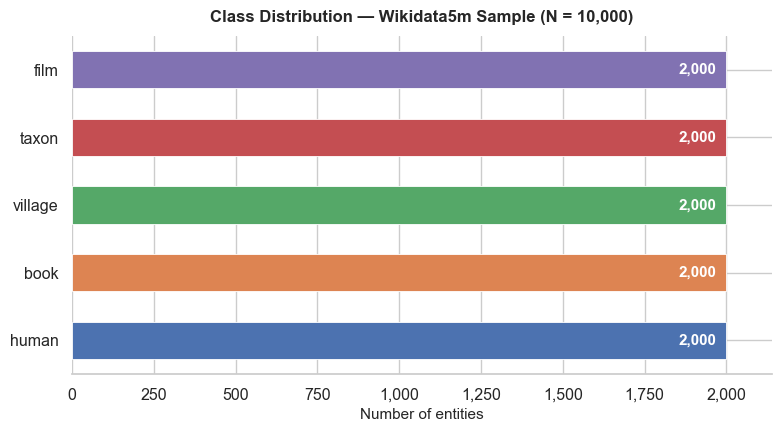

saved -> figures/eda_class_distribution.png

class       count  % of total
------------------------------
human       2,000       20.0%
book        2,000       20.0%
village     2,000       20.0%
taxon       2,000       20.0%
film        2,000       20.0%
------------------------------
TOTAL      10,000      100.0%


In [8]:
# ── 3.1 Class Distribution Bar Chart ─────────────────────────────────────────
class_counts = Counter(class_labels)
total        = sum(class_counts.values())
counts       = [class_counts[c] for c in CLASS_ORDER]
colours      = [PALETTE[c] for c in CLASS_ORDER]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(CLASS_ORDER, counts, color=colours,
               edgecolor='white', linewidth=0.6, height=0.55)

for bar, cnt in zip(bars, counts):
    ax.text(bar.get_width() - 30, bar.get_y() + bar.get_height() / 2,
            f'{cnt:,}', va='center', ha='right',
            color='white', fontsize=11, fontweight='bold')

ax.set_xlabel('Number of entities', fontsize=11)
ax.set_title('Class Distribution — Wikidata5m Sample (N = 10,000)',
             fontsize=12, fontweight='bold', pad=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, max(counts) * 1.07)
sns.despine(left=True, bottom=False)
plt.tight_layout()
fig.savefig('figures/eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved -> figures/eda_class_distribution.png')

print()
print(f"{'class':<10} {'count':>6}  {'% of total':>10}")
print('-' * 30)
for cls, cnt in zip(CLASS_ORDER, counts):
    print(f'{cls:<10} {cnt:>6,}  {cnt/total*100:>9.1f}%')
print('-' * 30)
print(f"{'TOTAL':<10} {total:>6,}  {'100.0':>9}%")


### Observations — Class Distribution

The dataset is **perfectly balanced**: each of the five classes contains exactly
2,000 entities (20% each), by construction (`random.seed(42)` sampling).

**Implication for modelling:** because class sizes are equal, accuracy and macro F1
are equivalent on this dataset. However, **macro F1** is still the safer default
metric — it is invariant to accidental class-size drift in future versions and gives
clearer signal when per-class performance differs (which is expected given the large
feature-density gap between `film` and `taxon`/`village`).


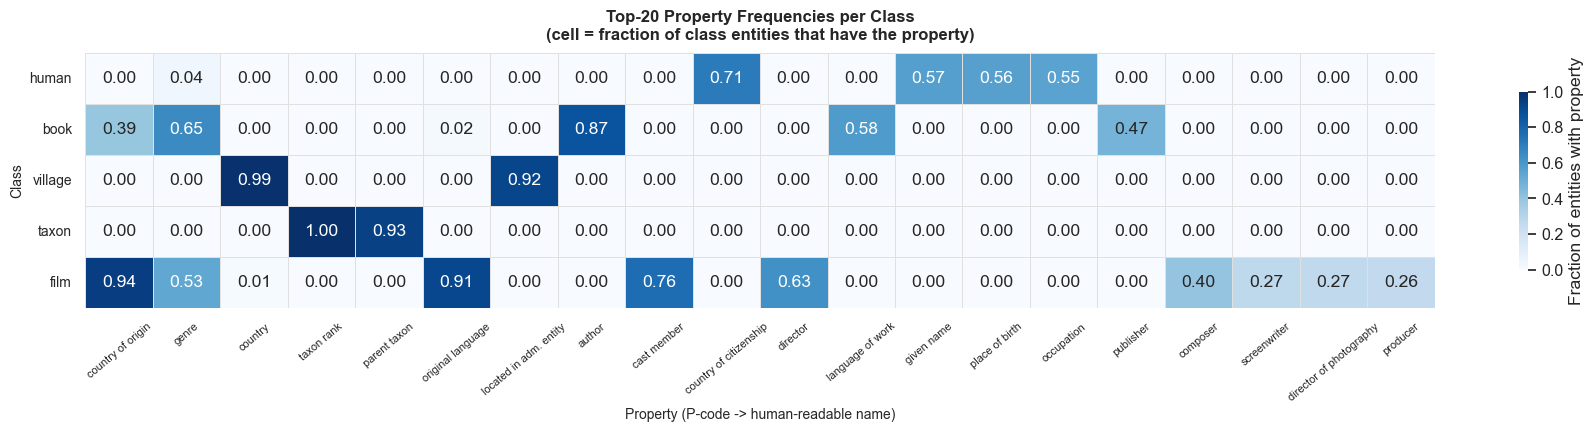

saved -> figures/eda_property_heatmap.png

rank  P-code    readable name                   global_freq
------------------------------------------------------------
   1  P495      country of origin               1.3360
   2  P136      genre                           1.2205
   3  P17       country                         1.0075
   4  P105      taxon rank                      0.9970
   5  P171      parent taxon                    0.9315
   6  P364      original language               0.9295
   7  P131      located in adm. entity          0.9170
   8  P50       author                          0.8675
   9  P161      cast member                     0.7645
  10  P27       country of citizenship          0.7135
  11  P57       director                        0.6305
  12  P407      language of work                0.5860
  13  P735      given name                      0.5670
  14  P19       place of birth                  0.5605
  15  P106      occupation                      0.5545
  16  P123 

In [9]:
# ── 3.2 Property Frequency Heatmap (Top-20) ──────────────────────────────────
freq_matrix  = np.zeros((len(CLASS_ORDER), len(columns)), dtype=np.float32)
class_to_row = {c: i for i, c in enumerate(CLASS_ORDER)}

for cls, row_idx in class_to_row.items():
    idx_list = class_indices[cls]
    sub      = matrix[idx_list, :]
    col_sums = np.asarray(sub.sum(axis=0)).flatten()
    freq_matrix[row_idx, :] = col_sums / len(idx_list)

global_freq   = freq_matrix.sum(axis=0)
top20_col_idx = np.argsort(global_freq)[::-1][:20]
heat_data     = freq_matrix[:, top20_col_idx]
top20_pcodes  = [columns[i] for i in top20_col_idx]
top20_labels  = [prop_names.get(p, p) for p in top20_pcodes]
top20_labels  = [lbl[:22] + '...' if len(lbl) > 23 else lbl for lbl in top20_labels]

fig, ax = plt.subplots(figsize=(18, 4.5))
sns.heatmap(
    heat_data, ax=ax,
    xticklabels=top20_labels,
    yticklabels=CLASS_ORDER,
    annot=True, fmt='.2f',
    cmap='Blues', vmin=0, vmax=1,
    linewidths=0.4, linecolor='#e0e0e0',
    cbar_kws={'label': 'Fraction of entities with property', 'shrink': 0.7}
)
ax.set_title(
    'Top-20 Property Frequencies per Class\n'
    '(cell = fraction of class entities that have the property)',
    fontsize=12, fontweight='bold', pad=10
)
ax.set_xlabel('Property (P-code -> human-readable name)', fontsize=10)
ax.set_ylabel('Class', fontsize=10)
ax.tick_params(axis='x', rotation=40, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=10)
plt.tight_layout()
fig.savefig('figures/eda_property_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved -> figures/eda_property_heatmap.png')

print()
print(f"{'rank':>4}  {'P-code':<8}  {'readable name':<30}  global_freq")
print('-' * 60)
for rank, (pidx, pcode) in enumerate(zip(top20_col_idx, top20_pcodes), 1):
    name = prop_names.get(pcode, '(unknown)')
    print(f'{rank:>4}  {pcode:<8}  {name:<30}  {global_freq[pidx]:.4f}')


### Observations — Property Heatmap

**Highly discriminative properties** (high frequency in one class, near-zero elsewhere):

1. **P105 (taxon rank)** — present in ~99.7% of `taxon` entities, essentially absent in all other classes. Near-perfect taxon detector.
2. **P171 (parent taxon)** — ~93.2% in `taxon`, ~0% elsewhere. Together with P105 it uniquely fingerprints biological taxa.
3. **P131 (located in adm. entity)** — ~91.6% in `village`, near-zero elsewhere. Strong geographic indicator.
4. **P27 (country of citizenship)** — ~71.4% in `human`, essentially absent in other classes.
5. **P50 (author)** — ~86.7% of `book` entities, near-zero in films, humans, taxa, or villages.
6. **P57 (director)** — ~62.7% of `film` entities, essentially absent elsewhere.

**Common properties** (high across multiple classes — less useful for classification):

1. **P495 (country of origin)** — high in `film` (~94.2%) and `book` (~39.4%). Cannot differentiate these two classes on its own.
2. **P136 (genre)** — shared between `book` (~65.0%) and `film` (~53.2%). Useful in combination but not alone.
3. **P364 (original language)** — predominantly `film` (~91.1%) but appears in books too.

**Why discriminative properties matter more:** a property firing at 0.99 for `taxon`
and 0.00 for all others provides near-perfect information gain. Common properties
contribute noise relative to signal. This motivates chi-squared selection in Week 2.


Overall density : 2.1581%
Sparsity        : 97.8419%

class           N    mean   median   min   max  zero-prop
--------------------------------------------------------------
human        2000    4.33      4.0     0    18     102 (5.1%)
book         2000    3.71      4.0     0    12      98 (4.9%)
village      2000    2.21      2.0     0     6       8 (0.4%)
taxon        2000    2.14      2.0     0     6       1 (0.1%)
film         2000    6.16      6.0     0    21      22 (1.1%)
--------------------------------------------------------------
ALL         10000    3.71      3.0     0    21     231 (2.3%)


/var/folders/jw/l9wz9__d6779t08n5nzsm3qw0000gn/T/ipykernel_39387/1565898487.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


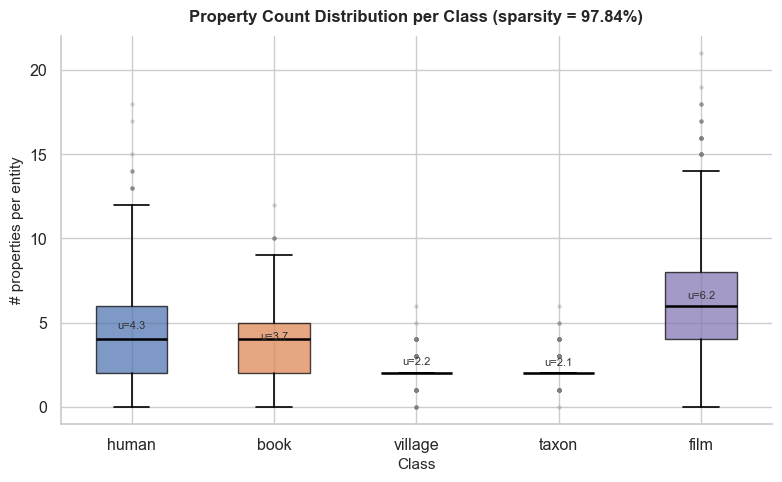

saved -> figures/eda_sparsity.png


In [10]:
# ── 3.3 Sparsity Analysis ─────────────────────────────────────────────────────
n_rows, n_cols = matrix.shape
density_pct    = matrix.nnz / (n_rows * n_cols) * 100
prop_counts    = np.asarray(matrix.sum(axis=1)).flatten()

print(f'Overall density : {density_pct:.4f}%')
print(f'Sparsity        : {100 - density_pct:.4f}%')
print()

class_prop_counts = {}
print(f"{'class':<10}  {'N':>5}  {'mean':>6}  {'median':>7}  {'min':>4}  {'max':>4}  {'zero-prop':>9}")
print('-' * 62)
for cls in CLASS_ORDER:
    idx  = class_indices[cls]
    pc   = prop_counts[idx]
    class_prop_counts[cls] = pc
    zero = int((pc == 0).sum())
    print(f'{cls:<10}  {len(idx):>5}  {pc.mean():>6.2f}  {np.median(pc):>7.1f}  '
          f'{pc.min():>4.0f}  {pc.max():>4.0f}  {zero:>6} ({zero/len(idx)*100:.1f}%)')
print('-' * 62)
print(f"{'ALL':<10}  {n_rows:>5}  {prop_counts.mean():>6.2f}  {np.median(prop_counts):>7.1f}  "
      f"{prop_counts.min():>4.0f}  {prop_counts.max():>4.0f}  "
      f"{int((prop_counts==0).sum()):>6} ({(prop_counts==0).mean()*100:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 5))
plot_data = [class_prop_counts[c] for c in CLASS_ORDER]
bp = ax.boxplot(
    plot_data, labels=CLASS_ORDER, patch_artist=True,
    medianprops=dict(color='black', linewidth=1.8),
    flierprops=dict(marker='o', markersize=3, alpha=0.35,
                    markerfacecolor='grey', markeredgewidth=0),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
)
for patch, cls in zip(bp['boxes'], CLASS_ORDER):
    patch.set_facecolor(PALETTE[cls])
    patch.set_alpha(0.72)

ax.set_xlabel('Class', fontsize=11)
ax.set_ylabel('# properties per entity', fontsize=11)
ax.set_title(
    f'Property Count Distribution per Class (sparsity = {100-density_pct:.2f}%)',
    fontsize=12, fontweight='bold', pad=10
)
for i, cls in enumerate(CLASS_ORDER, 1):
    mu = class_prop_counts[cls].mean()
    ax.text(i, mu + 0.15, f'u={mu:.1f}', ha='center', va='bottom', fontsize=8, color='#333')

sns.despine()
plt.tight_layout()
fig.savefig('figures/eda_sparsity.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved -> figures/eda_sparsity.png')


### Observations — Sparsity & Week 2 Feature Selection

The feature matrix is **97.84% sparse**. Per-entity property counts are right-skewed:
`film` entities average ~6.2 properties while `taxon` and `village` average ~2.1.

| Technique | Why applicable |
|-----------|---------------|
| **Variance threshold** | Remove features present in < 0.5% of entities — near-zero variance. |
| **Chi-squared (χ²) selection** | Binary features + categorical target = ideal fit. Identifies class-specific properties. Select top-k (k = 30, 50, 80). |
| **TruncatedSVD** | Sparse-friendly dimensionality reduction without densifying the matrix. |
| **Avoid PCA** | Densifies the matrix; produces real-valued features from binary data — not ideal. |

Tree-based models (Random Forest, XGBoost) and sparse-aware linear classifiers
(logistic regression with L1, linear SVM) are the natural Week 2 starting points.


In [11]:
# ── 3.4 Data Quality Audit ────────────────────────────────────────────────────
EXPECTED_CLASSES = {'human', 'book', 'village', 'taxon', 'film'}
checks = []

# 1: row count match
rc_match = matrix.shape[0] == len(labels)
checks.append(('matrix rows == labels rows',
               'PASS' if rc_match else 'FAIL',
               f'{matrix.shape[0]} vs {len(labels)}'))

# 2: column count match
col_match = matrix.shape[1] == len(columns)
checks.append(('matrix cols == columns list',
               'PASS' if col_match else 'FAIL',
               f'{matrix.shape[1]} vs {len(columns)}'))

# 3: unexpected class values
found_classes = set(row['class_name'] for row in labels)
unexpected    = found_classes - EXPECTED_CLASSES
missing       = EXPECTED_CLASSES - found_classes
class_ok      = (not unexpected) and (not missing)
checks.append(('class values in expected set',
               'PASS' if class_ok else 'FAIL',
               'all 5 classes present' if class_ok else f'unexpected={unexpected}, missing={missing}'))

# 4: duplicate entity IDs
entity_ids = [row['entity_id'] for row in labels]
n_dupes    = len(entity_ids) - len(set(entity_ids))
checks.append(('no duplicate entity IDs',
               'PASS' if n_dupes == 0 else f'FAIL ({n_dupes} dupes)',
               f'{n_dupes} duplicate(s) found'))

# 5: zero-property entities
zero_mask   = prop_counts == 0
n_zero      = int(zero_mask.sum())
zero_by_cls = {cls: int((prop_counts[class_indices[cls]] == 0).sum()) for cls in CLASS_ORDER}
checks.append(('entities with 0 properties',
               f'WARN ({n_zero} affected)',
               ', '.join(f'{c}:{zero_by_cls[c]}' for c in CLASS_ORDER)))

# 6: P31 data leakage guard
p31_present = 'P31' in columns
checks.append(('P31 absent from features (no data leak)',
               'FAIL - DATA LEAK' if p31_present else 'PASS',
               'P31 encodes the class label'))

# 7: binary-only values
unique_vals = set(matrix.data.tolist())
all_binary  = unique_vals.issubset({1})
checks.append(('all non-zero values == 1 (binary)',
               'PASS' if all_binary else 'FAIL',
               f'unique non-zero values: {sorted(unique_vals)}'))

print('=' * 70)
print('  DATA QUALITY REPORT — Group 5B, Section 3.4')
print('=' * 70)
for name, status, detail in checks:
    icon = '[PASS]' if status == 'PASS' else ('[WARN]' if 'WARN' in status else '[FAIL]')
    print(f'  {icon}  {status:<28}  {name}')
    print(f'         {detail}')
    print()
print('=' * 70)


  DATA QUALITY REPORT — Group 5B, Section 3.4
  [PASS]  PASS                          matrix rows == labels rows
         10000 vs 10000

  [PASS]  PASS                          matrix cols == columns list
         172 vs 172

  [PASS]  PASS                          class values in expected set
         all 5 classes present

  [PASS]  PASS                          no duplicate entity IDs
         0 duplicate(s) found

  [WARN]  WARN (231 affected)           entities with 0 properties
         human:102, book:98, village:8, taxon:1, film:22

  [PASS]  PASS                          P31 absent from features (no data leak)
         P31 encodes the class label

  [PASS]  PASS                          all non-zero values == 1 (binary)
         unique non-zero values: [1]



### Data Quality Findings & Decisions

**What we found:**
- Row/column alignment: matrix and labels.csv match exactly (10,000 rows, 172 columns).
- Class values: all five expected classes present; no spurious values.
- Duplicate entity IDs: none detected.
- **Zero-property entities (231 total, 2.31%):** 102 human, 98 book, 22 film, 8 village, 1 taxon have all-zero feature vectors. These entities appear in Wikidata5m only via their P31 triple — no other predicates were recorded. Distance-based models will conflate them.
- P31 absent: confirmed — the class-label property is correctly excluded from features.
- Binary values: all non-zero entries are exactly 1. Valid binary indicator matrix.

**Decisions:**
1. **Keep zero-property entities.** Dropping 2.31% of data would bias class distributions. In Week 2 we will add a `has_any_property` binary indicator feature.
2. No de-duplication needed — entity IDs are unique.
3. Column order is locked — never sort/shuffle `labels.csv` and `feature_matrix.npz` independently; their row alignment is critical.
4. Class balance confirmed (2,000/class) — no re-sampling needed.


## Section 4 -- Data Preparation

_To be filled in Week 2._

## Section 5 -- Modeling

_To be filled in Week 2._

## Section 6 -- Evaluation

_To be filled in Week 2._

## Section 7 -- Insights & Discussion

_To be filled in Week 3._